In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df=pd.read_csv("../raw_datasets/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [26]:
df.nunique()

CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64

In [27]:
# delete the 'CustomerID' column as it is not useful for analysis
df.drop('CustomerID', axis=1, inplace=True)

In [28]:
# label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() 
df['Gender']=le.fit_transform(df['Gender'])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int32
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int32(1), int64(3)
memory usage: 5.6 KB


In [30]:
# check for missing values
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

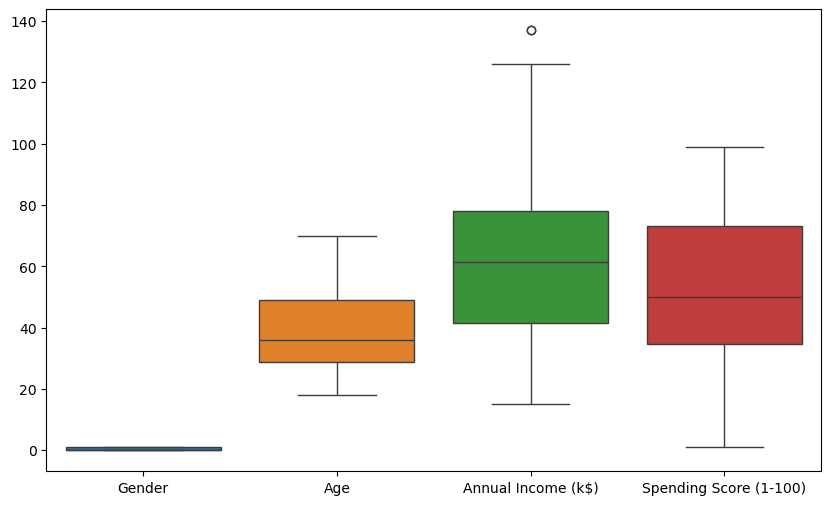

In [31]:
# outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()

In [32]:
# remove outliers
for col in df.columns:
    if df[col].dtype!='object':
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]

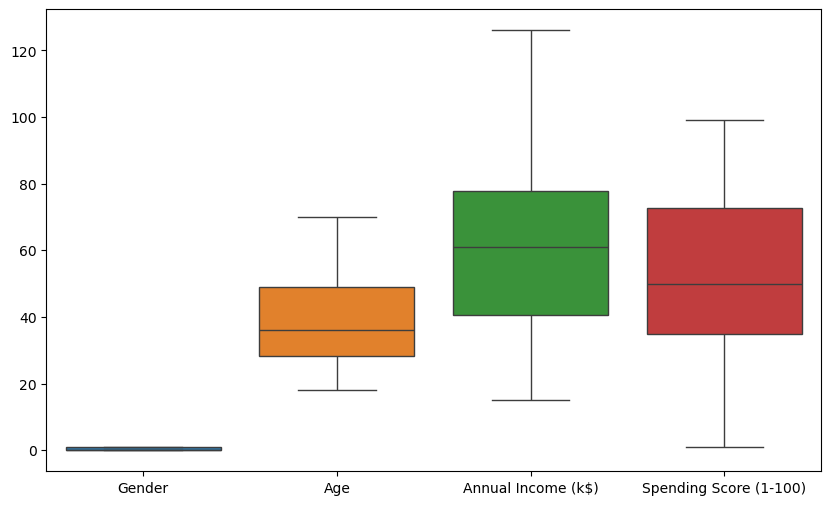

In [33]:
# check for outliers again
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()

<Axes: >

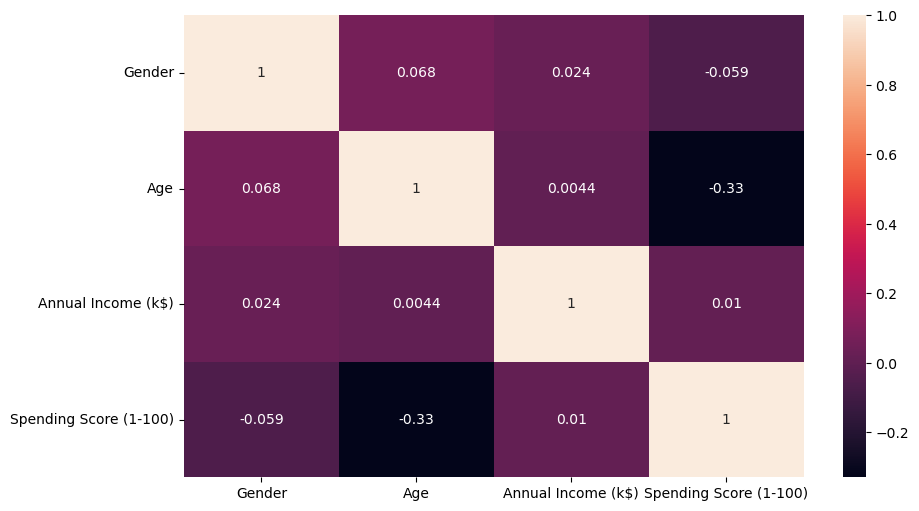

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)

In [35]:
# standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.141195,-1.425414,-1.779171,-0.435989
1,1.141195,-1.282367,-1.779171,1.199413
2,-0.876275,-1.353890,-1.739447,-1.720949
3,-0.876275,-1.139319,-1.739447,1.043661
4,-0.876275,-0.567131,-1.699723,-0.397051


<Axes: >

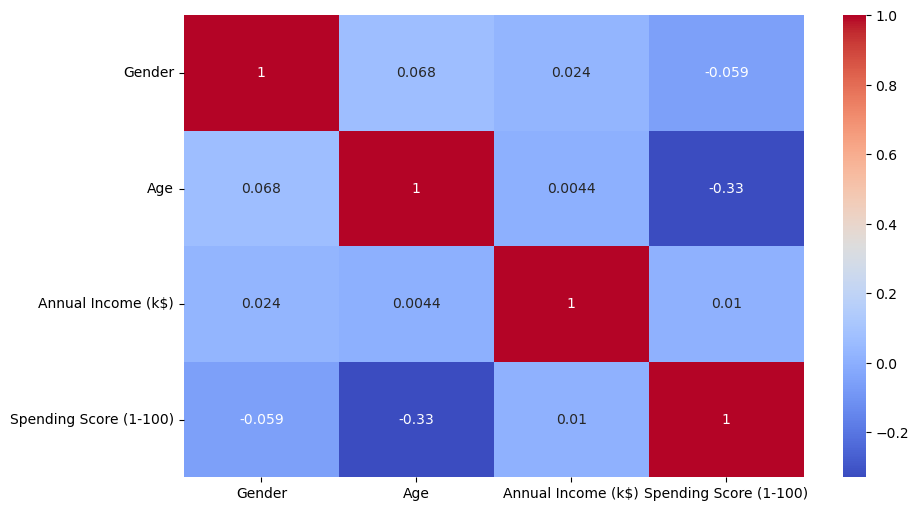

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

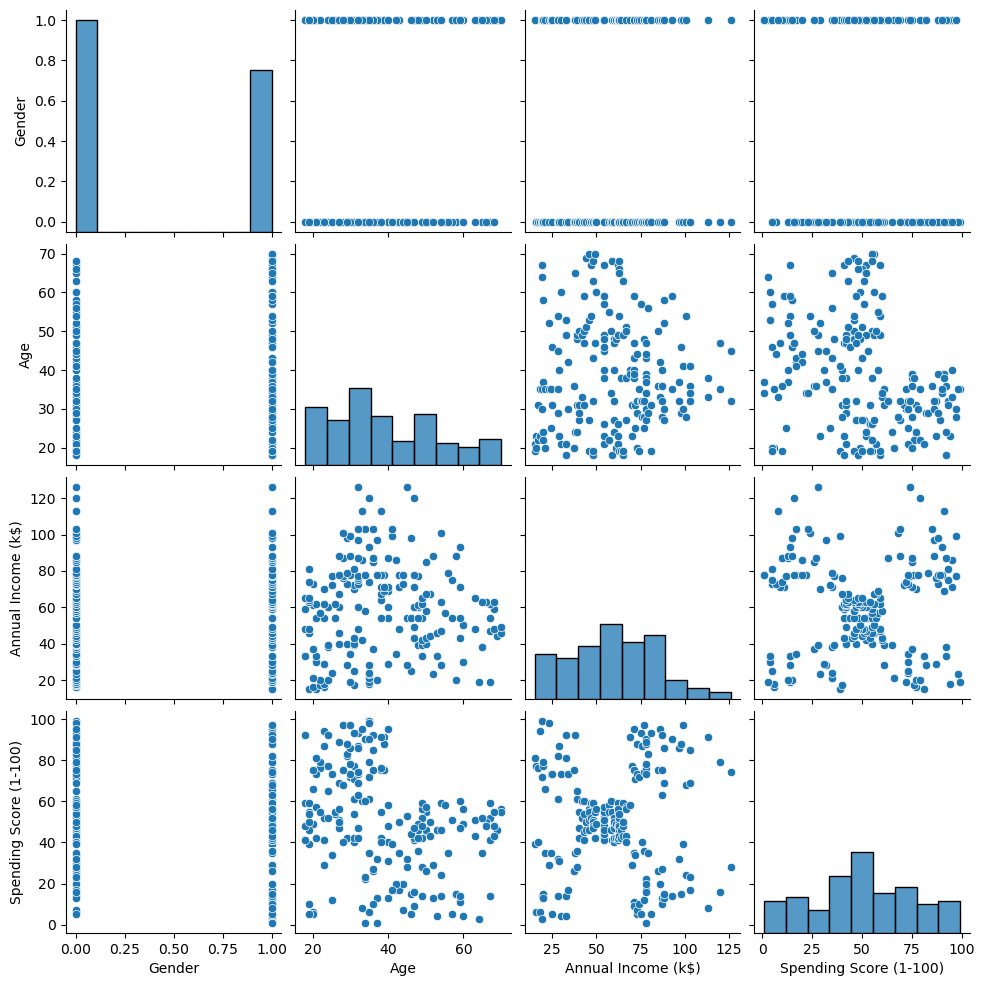

In [37]:
# pairplot
sns.pairplot(df)

In [38]:
# dbscan clustering
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(scaled_df)
df['DBSCAN_Cluster'] = dbscan.labels_

In [39]:
# shilhouette score
from sklearn.metrics import silhouette_score
silhouette_score(scaled_df, dbscan.labels_)

0.0007296552640720114

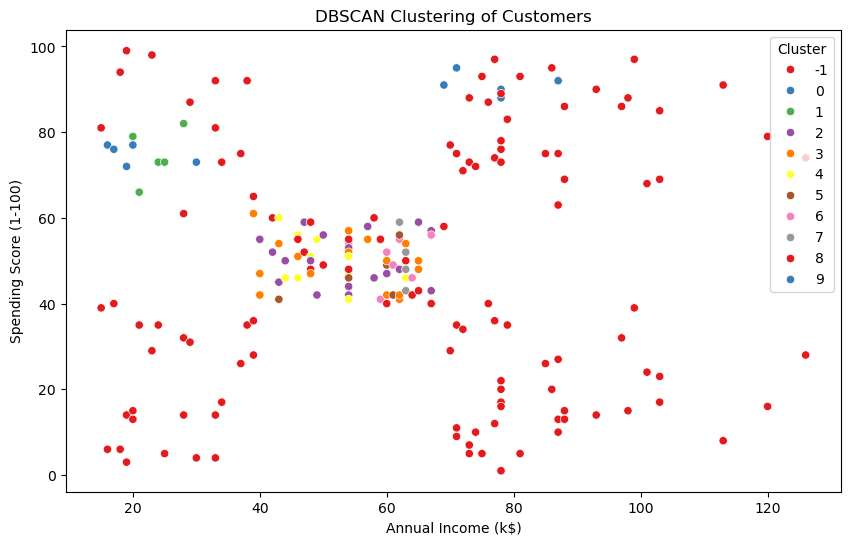

In [40]:
# plotting the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=df, palette='Set1')
plt.title('DBSCAN Clustering of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

c:\Users\keert\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Text(0.5, 1.0, 'KMeans Clustering of Customers')

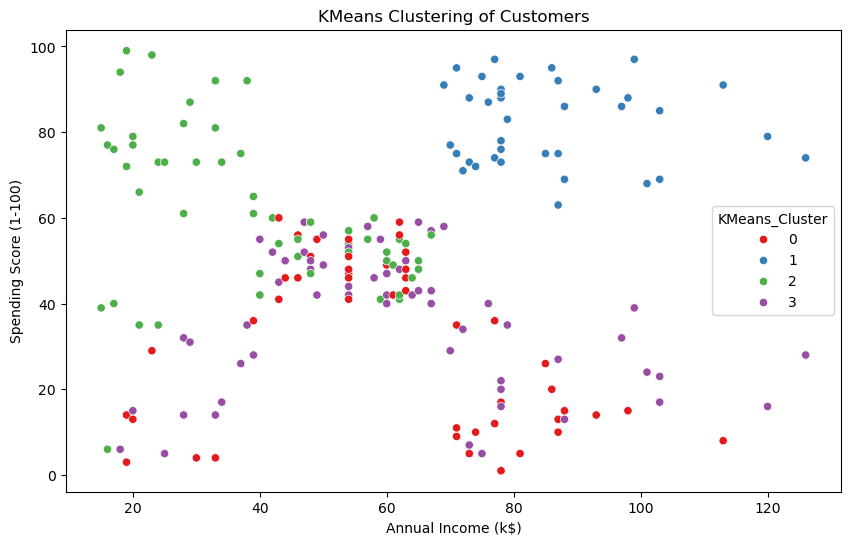

In [41]:
# kmeans clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(scaled_df)
df['KMeans_Cluster'] = kmeans.labels_
# plotting the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', data=df, palette='Set1')
plt.title('KMeans Clustering of Customers')

In [44]:
# sihouette score for kmeans
silhouette_score(scaled_df, kmeans.labels_)

0.2989514866332462

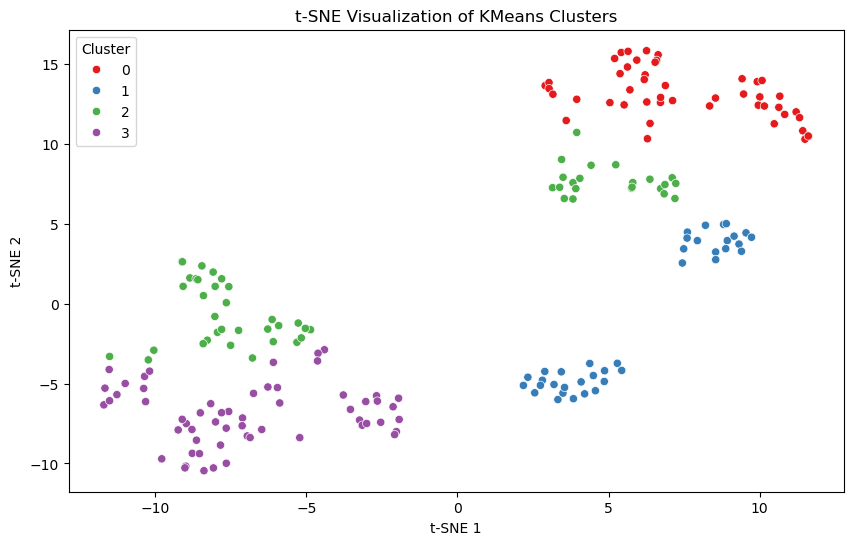

In [42]:
# t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(scaled_df)
df['TSNE_1'] = tsne_results[:,0]
df['TSNE_2'] = tsne_results[:,1]
plt.figure(figsize=(10,6))
sns.scatterplot(x='TSNE_1', y='TSNE_2', hue='KMeans_Cluster', data=df, palette='Set1')
plt.title('t-SNE Visualization of KMeans Clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster')
plt.show()

In [43]:
# silhouette score for t-SNE
silhouette_score(df[['TSNE_1', 'TSNE_2']], df['KMeans_Cluster'])


0.37890255

In [45]:
# hirearchial clustering
from sklearn.cluster import AgglomerativeClustering
agg_clustering = AgglomerativeClustering(n_clusters=4)
agg_clustering.fit(scaled_df)
df['Agglomerative_Cluster'] = agg_clustering.labels_

In [46]:
# sihouette score for hirearchial clustering
silhouette_score(scaled_df, agg_clustering.labels_)

0.2601728939012523

In [47]:
# divisive clustering
divisive_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')

In [48]:
# sihouette score for divisive clustering
silhouette_score(scaled_df, divisive_clustering.fit_predict(scaled_df))

0.2601728939012523

In [50]:
# gmm clustering
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(scaled_df)
df['GMM_Cluster'] = gmm.predict(scaled_df)
silhouette_score(scaled_df, df['GMM_Cluster'])

c:\Users\keert\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0.18795018985915377

In [52]:
data=pd.read_csv("../raw_datasets/Mall_Customers.csv")
data.drop('CustomerID', axis=1, inplace=True)
data.to_csv("../processed_datasets/Mall_Customers.csv", index=False)